 Total Force: 0.000000, Simulation time: 0.0013 s / 300.0000 s, dt: 0.001250 s, Elapsed time: 0.02 s
 Total Force: 0.000000, Simulation time: 0.0026 s / 300.0000 s, dt: 0.001375 s, Elapsed time: 0.02 s
 Total Force: 0.000000, Simulation time: 0.0041 s / 300.0000 s, dt: 0.001513 s, Elapsed time: 0.02 s
 Total Force: 0.000000, Simulation time: 0.0058 s / 300.0000 s, dt: 0.001664 s, Elapsed time: 0.03 s
 Total Force: 0.000000, Simulation time: 0.0076 s / 300.0000 s, dt: 0.001830 s, Elapsed time: 0.03 s
 Total Force: 0.000000, Simulation time: 0.0096 s / 300.0000 s, dt: 0.002013 s, Elapsed time: 0.03 s
 Total Force: 0.000000, Simulation time: 0.0119 s / 300.0000 s, dt: 0.002214 s, Elapsed time: 0.03 s
 Total Force: 0.000000, Simulation time: 0.0143 s / 300.0000 s, dt: 0.002436 s, Elapsed time: 0.04 s
 Total Force: 0.000000, Simulation time: 0.0170 s / 300.0000 s, dt: 0.002679 s, Elapsed time: 0.04 s
 Total Force: 0.000000, Simulation time: 0.0199 s / 300.0000 s, dt: 0.002947 s, Elapsed tim

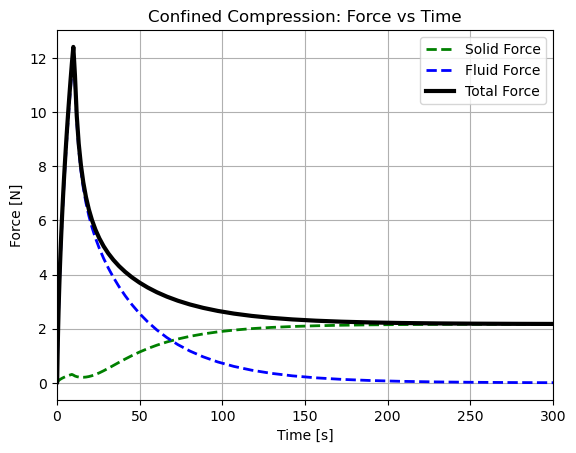

In [1]:
from up_formulation import *
import numpy as np
import time as time
import matplotlib.pyplot as plt
'''
Compression of a Poroelastic cylinder

Confined = True : Confined Compression
Confined = False : Unconfined Compression

Draw Results = True : Draws results in WebGUI

'''
Confined = True
DrawResults = False
R = 3.6 * 10**(-3) # [m] Radius of the cylindrical sample
H = 1e-3 # [m] Height of the cylindrical sample

# Material Properties

nu = 0.2 # Poisson's ratio
G = 2e5
alpha = 0.9 # Biot coefficient
k = 5e-18 # [m^2] Intrinsic Permeability
phi = 0.8 # Porosity
viscosity = 1e-3 # [N s] Fluid viscosity
chi = 1e-10 # [Pa^-1] Fluid Compressibility
rho = 1000 # [kg/m^3] Fluid density
g = -9.81 # [m/s^2] Gravitational acceleration

# Simulation Parameters

dt = 1.25e-3 # [s] Starting Time step size
dt_max = 1000 # [s] Maximum time step size for dynamic time stepping
t_end = 300 # [s] Total simulation time
dt_growth = 1.1 # Growth factor for dynamic time stepping

u_max = H*0.1 # [m] Maximum displacement of the compression
compression_time = 92.6/10 # [s] Time duration for which the compression is applied

# Mesh Parameters
nx = 10 # Number of elements in X direction (radial)
ny = 10 # Number of elements in Y direction (axial)
order = 2 # Polynomial order for the finite element space
grading = 0.95 # Mesh grading parameter, controls bias of elements near the surface
 
# Solver tolerance
tol = 1e-8

# Timing code
t0 = time.time()
time_vals, F_solid, F_fluid = ConfinedCompression(G, nu, viscosity, alpha, phi, k,
     chi, rho, g, dt, dt_max, dt_growth, R, H, u_max , compression_time, t_end, nx,
     ny, grading, order, tol, Confined, DrawResults)
t1 = time.time()
print("Simulation time: ", t1 - t0, " seconds", flush=True)
plt.plot(time_vals, F_solid,'--', color='green',lw=2,  label='Solid Force')
plt.plot(time_vals, F_fluid,'--', color='blue',lw=2,  label='Fluid Force')
plt.plot(np.array(time_vals), np.array(F_solid) + np.array(F_fluid), label='Total Force', linestyle='-', color='black', lw=3)
plt.xlabel('Time [s]')
plt.ylabel('Force [N]')
plt.title('Confined Compression: Force vs Time')
plt.legend()
plt.grid()
plt.xlim(0, 300)
print('max force = ' + str(np.max(F_solid + F_fluid)))
plt.show()







In [2]:

from up_formulation import *
import numpy as np
import time as time
import matplotlib.pyplot as plt


Confined = True
DrawResults = False

# Geometry
R = 0.2 # [m] Radius of the cylindrical sample
H = 1 # [m] Height of the cylindrical sample

# Material Properties


G = 1e5  # [Pa] Shear modulus
nu = 0.49 # Poisson's ratio
alpha = 1.0 # Biot coefficient
k = 1e-12 # [m^2] Intrinsic Permeability
phi = 0.75 # Porosity
viscosity = 1e-3 # [N s] Fluid viscosity
chi = 1e-10 # [Pa^-1] Fluid Compressibility
rho = 1000 # [kg/m^3] Fluid density
g = 0 # [m/s^2] Gravitational acceleration

# Simulation Parameters

dt = 0.01 # [s] Starting Time step size
dt_max = 1000 # [s] Maximum time step size for dynamic time stepping
t_end = 1000 # [s] Total simulation time
dt_growth = 1.01 # Growth factor for dynamic time stepping

traction = -1000 # Traction applied to top surface

# Mesh Parameters
nx = 10 # Number of elements in X direction (radial)
ny = 20 # Number of elements in Y direction (axial)
order = 3 # Polynomial order for the finite element space
grading = 0.95 # Mesh grading parameter, controls bias of elements near the surface
 
# Solver tolerance
tol = 1e-12


heights = np.linspace(0, H, 50) # 50 points along the column

# Timing code
t0 = time.time()
time_vals, all_p_values, displacement_max = Consolidation(G, nu, viscosity, alpha, phi, k, chi, rho, g, dt, dt_max, dt_growth, R, H, traction, t_end, nx, ny, grading, order, tol, Confined, DrawResults)
t1 = time.time()


import numpy as np

def terzaghi_analytical(z, t, H, P0, k, mu, E, nu, alpha, n, chi, terms=100):
    # 1. Skeleton Confined Modulus
    M_v = (E * (1 - nu)) / ((1 + nu) * (1 - 2 * nu))
    
    # 2. Biot Modulus (1/M in many papers)
    # This accounts for fluid compressibility and porosity
    inv_M = n * chi 
    
    # 3. Refined Consolidation Coefficient
    # cv = mobility / (storage_capacity)
    storage_capacity = inv_M + (alpha**2 / M_v)
    cv = (k / mu) / storage_capacity
    # 3. Fourier Series Summation
    p_sum = 0
    for m in range(terms):
        n = 2 * m + 1  # Only odd terms
        term_val = (1 / n) * np.sin(n * np.pi * z / (2 * H)) * \
                   np.exp(-(n**2 * np.pi**2 * cv * t) / (4 * H**2))
        p_sum += term_val
        
    return (4 * P0 / np.pi) * p_sum

def analytical_settlement(t, H, P0, E, nu, k, mu, terms=100):
    """
    Calculates the vertical settlement at the top of the column.
    
    Parameters:
    t  : Time (s)
    H  : Column height (m)
    P0 : Applied traction (Pa)
    E  : Young's Modulus (Pa)
    nu : Poisson's ratio
    k  : Permeability (m^2)
    mu : Fluid viscosity (Pa*s)
    """
    # 1. Calculate the Constrained Modulus (Mv) for nu != 0
    M_v = (E * (1 - nu)) / ((1 + nu) * (1 - 2 * nu))
    
    # 2. Calculate the Consolidation Coefficient (cv)
    # This assumes Terzaghi limits (alpha=1, incompressible fluid)
    cv = (k / mu) * M_v
    
    # 3. Calculate Ultimate Settlement (w_infinity)
    w_inf = (P0 * H) / M_v
    
    # 4. Infinite Series Summation
    s_sum = 0
    for m in range(terms):
        n = 2 * m + 1
        # The exponential term is the same as the pressure solution
        exponent = np.exp(-(n**2 * np.pi**2 * cv * t) / (4 * H**2))
        # Settlement uses 1/n^2
        s_sum += (1 / n**2) * exponent
        
    # The final formula: w(t) = w_inf * (1 - (8/pi^2) * sum)
    settlement = w_inf * (1 - (8 / np.pi**2) * s_sum)
    
    return settlement


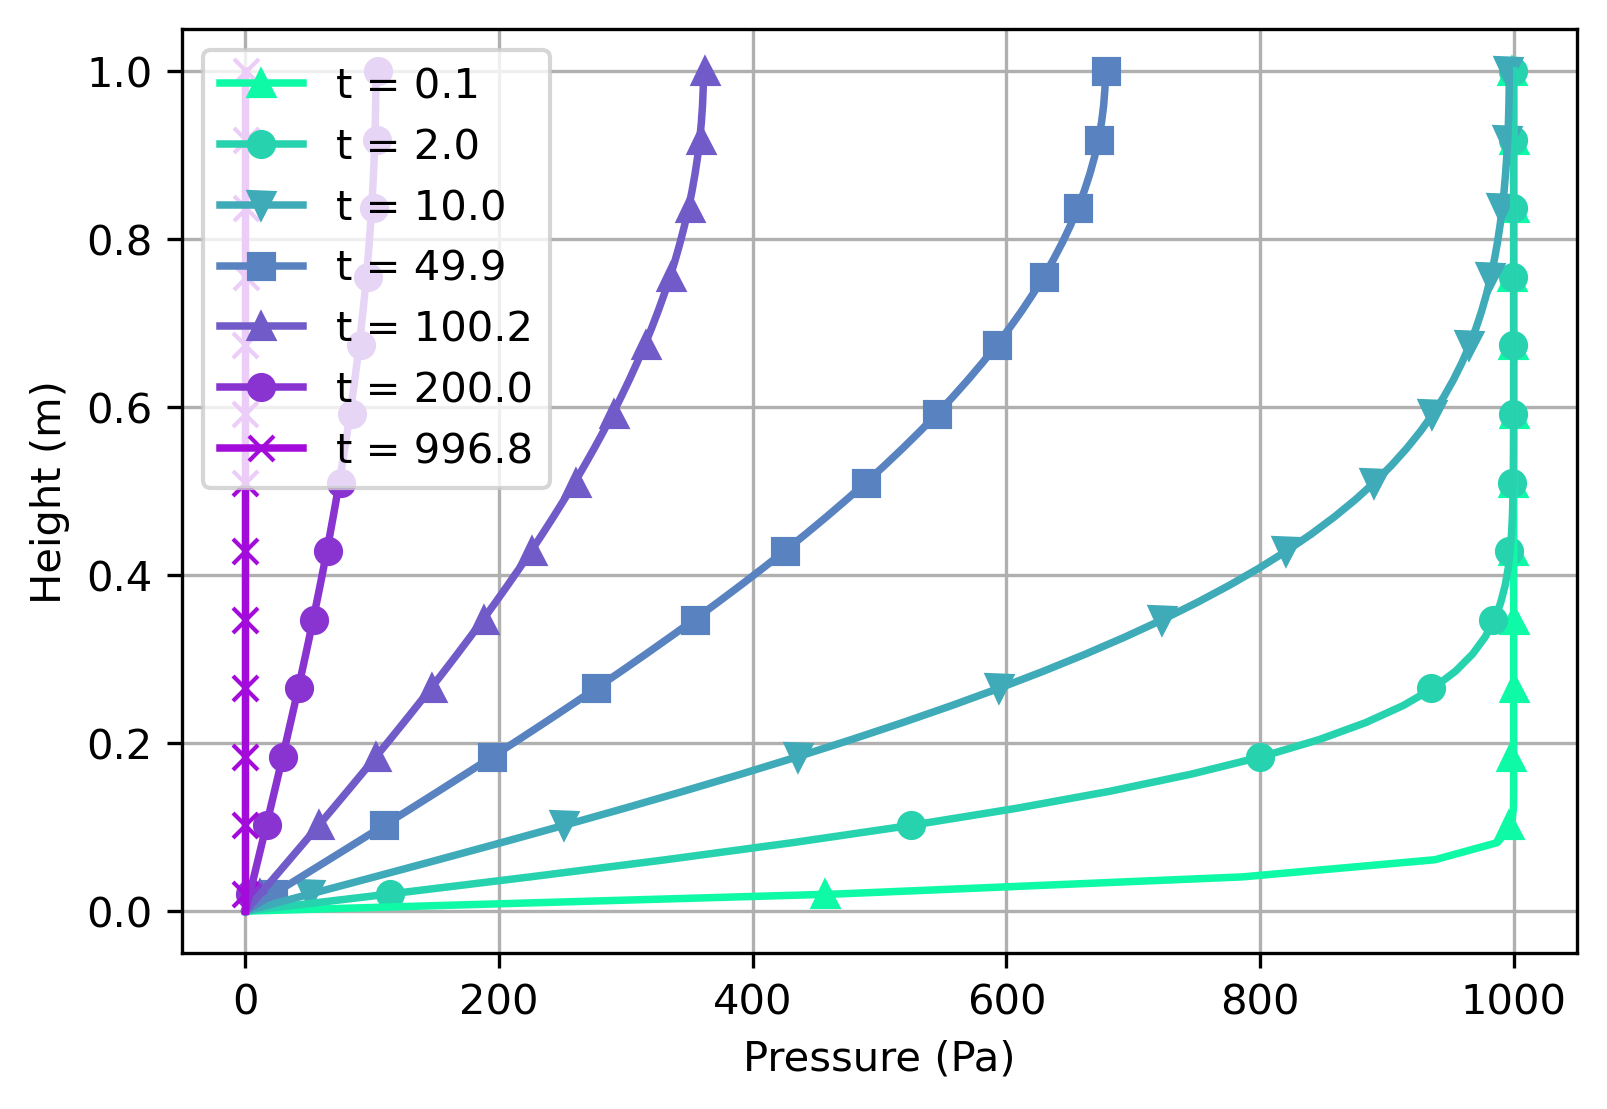

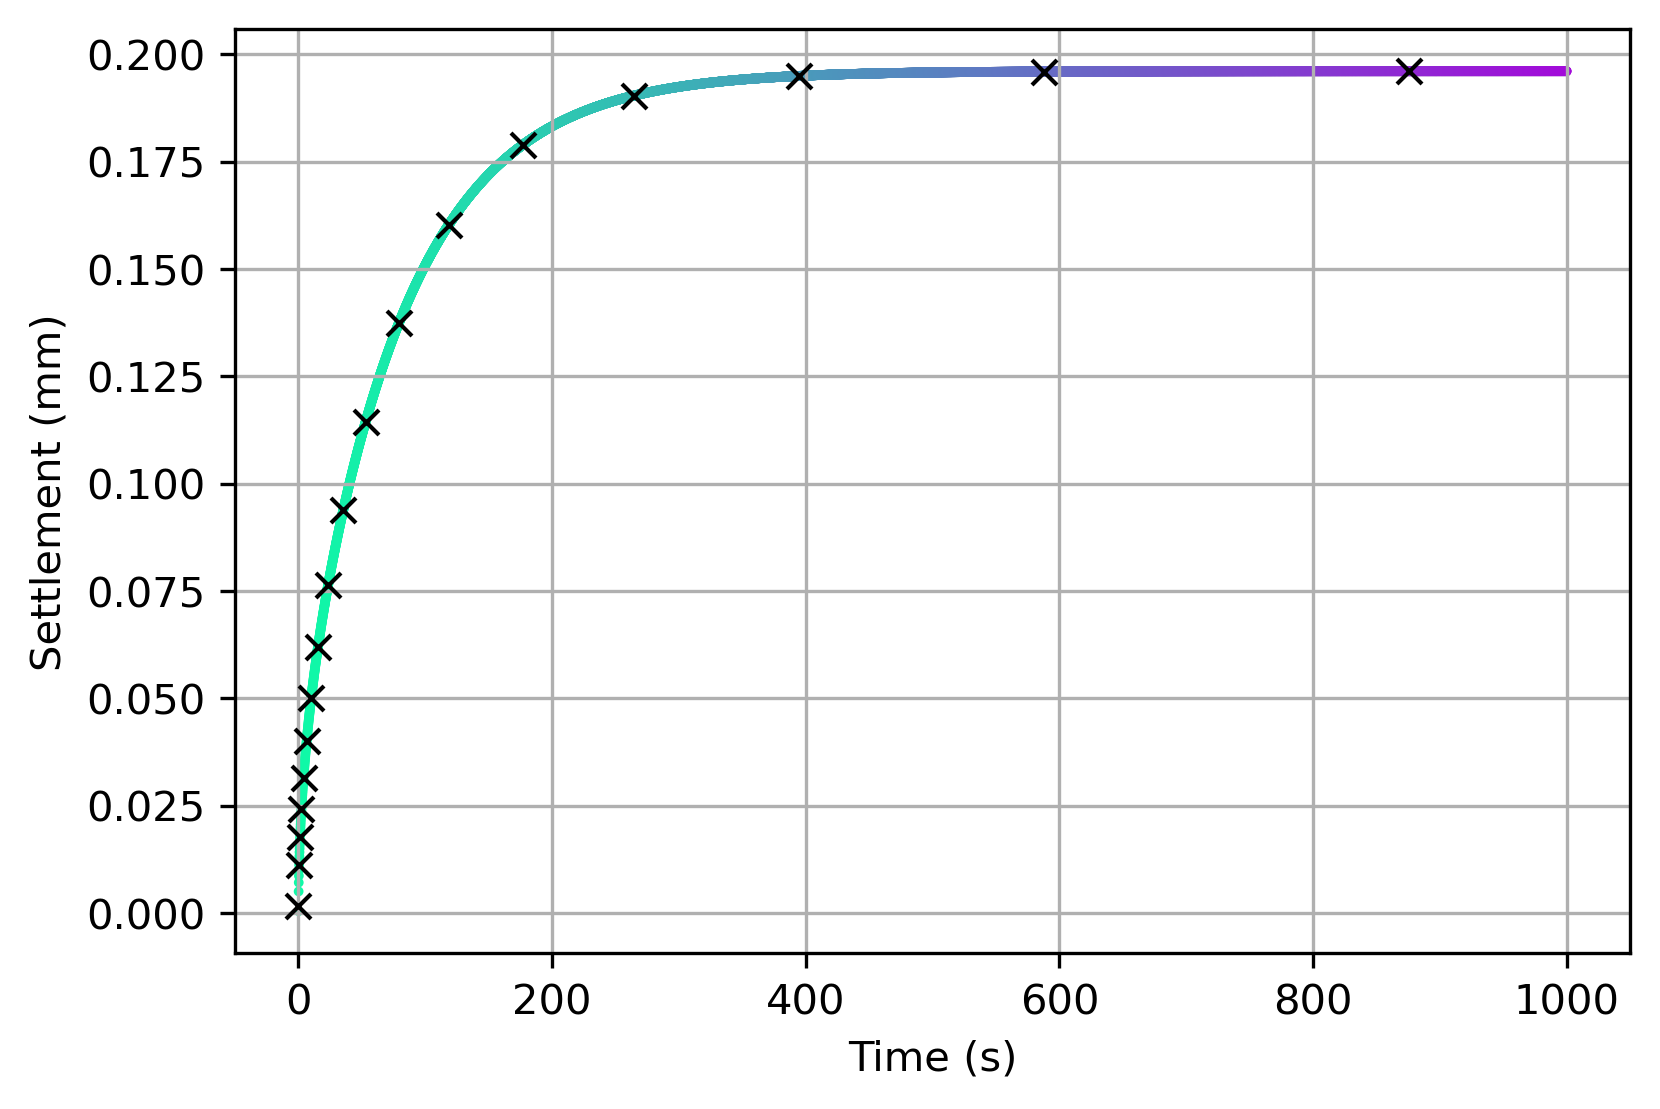

In [ ]:


idx1 = 10
idx2 = 110
idx3 = 240
idx4 = 394
idx5 = 463
idx6 = 532
idx7 = -1
E = YoungsModulus(G, nu)


t_2_0 = terzaghi_analytical(heights, time_vals[idx1], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_10_0 = terzaghi_analytical(heights, time_vals[idx2], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_20_0 = terzaghi_analytical(heights, time_vals[idx3], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_50_0 = terzaghi_analytical(heights, time_vals[idx4], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_100_0 = terzaghi_analytical(heights, time_vals[idx5], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_200_0 = terzaghi_analytical(heights, time_vals[idx6], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)
t_1000 = terzaghi_analytical(heights, time_vals[idx7], H=1, P0=1000, k=k, mu=viscosity, E=E, nu=nu, alpha=alpha, n=0.75, chi=chi)

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]

color1 = "#0EFAA7"
color2 = "#A20BD99C"


idx1 = 10
idx2 = 110
idx3 = 240
idx4 = 394
idx5 = 463
idx6 = 532
idx7 = -1

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Pressure Profile Metrics ---
pressure_indices = [idx1, idx2, idx3, idx4, idx5, idx6]
analytical_profiles = [t_2_0, t_10_0, t_20_0, t_50_0, t_100_0, t_200_0]


for i, idx in enumerate(pressure_indices):
    y_true = analytical_profiles[i]
    
    # Apply np.flip to the FE data to align the spatial points
    # This matches your plot's logic: ax1.plot(all_p_values[idx1], np.flip(heights)...)
    y_pred = np.flip(all_p_values[idx])
    
    mse_p = mean_squared_error(y_true, y_pred)
    r2_p = r2_score(y_true, y_pred)
    

# --- Settlement Curve Metrics (No flip needed for time-series) ---

y_true_settle = analytical_settlement(t=time_vals, H=1, P0=1000, E=E, nu=nu, k=k, mu=viscosity) * 1000
y_pred_settle = np.array(displacement_max) * 1000

mse_s = mean_squared_error(y_true_settle, y_pred_settle)
r2_s = r2_score(y_true_settle, y_pred_settle)

# --- Metric Calculations ---
pressure_indices = [idx1, idx2, idx3, idx4, idx5]
analytical_profiles = [t_2_0, t_10_0, t_20_0, t_50_0, t_100_0, t_200_0]

r2_list = []
for i, idx in enumerate(pressure_indices):
    y_true = analytical_profiles[i]
    y_pred = np.flip(all_p_values[idx])  # Correcting the spatial mirroring
    r2_list.append(r2_score(y_true, y_pred))

avg_r2_p = np.mean(r2_list)

plt.figure(figsize=(6,4), dpi=300)



t_vals_interp = np.linspace(0, 1000, 10001)

idy1 = 0
idy2 = 1
idy3 = 2
idy4 = 3
idy5 = 4
idy6 = 5
idy7 = 6

plt.plot(all_p_values[idx1], np.flip(heights), '^', color=get_color_gradient(color1, color2, 7)[idy1], markevery=4)
plt.plot(all_p_values[idx2], np.flip(heights), 'o', color=get_color_gradient(color1, color2, 7)[idy2], markevery=4)
plt.plot(all_p_values[idx3], np.flip(heights), 'v', color=get_color_gradient(color1, color2, 7)[idy3], markevery=4)
plt.plot(all_p_values[idx4], np.flip(heights), 's', color=get_color_gradient(color1, color2, 7)[idy4], markevery=4)
plt.plot(all_p_values[idx5], np.flip(heights), '^', color=get_color_gradient(color1, color2, 7)[idy5], markevery=4)
plt.plot(all_p_values[idx6], np.flip(heights), 'o', color=get_color_gradient(color1, color2, 7)[idy6], markevery=4)
plt.plot(all_p_values[idx7], np.flip(heights), 'x', color=get_color_gradient(color1, color2, 7)[idy7], markevery=4)

plt.plot(t_2_0, heights, color = get_color_gradient(color1, color2, 7)[idy1], lw=1.8, label=f't = {time_vals[idx1]:.1f}')
plt.plot(t_10_0, heights, color = get_color_gradient(color1, color2, 7)[idy2], lw=1.8, label=f't = {time_vals[idx2]:.1f}')
plt.plot(t_20_0, heights, color = get_color_gradient(color1, color2, 7)[idy3], lw=1.8, label=f't = {time_vals[idx3]:.1f}')
plt.plot(t_50_0, heights, color = get_color_gradient(color1, color2, 7)[idy4], lw=1.8, label=f't = {time_vals[idx4]:.1f}')
plt.plot(t_100_0, heights, color = get_color_gradient(color1, color2, 7)[idy5], lw=1.8, label=f't = {time_vals[idx5]:.1f}')
plt.plot(t_200_0, heights, color = get_color_gradient(color1, color2, 7)[idy6], lw=1.8, label=f't = {time_vals[idx6]:.1f}')
plt.plot(t_1000, heights, color = get_color_gradient(color1, color2, 7)[idy7], lw=1.8, label=f't = {time_vals[idx7]:.1f}')

#plt.title(f"Pressure Profiles ($R^2$: {avg_r2_p:.4f})")
plt.xlabel('Pressure (Pa)')
plt.ylabel('Height (m)')
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy1], marker='^', lw=1.8,
           label=f't = {time_vals[idx1]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy2], marker='o', lw=1.8,
           label=f't = {time_vals[idx2]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy3], marker='v', lw=1.8,
           label=f't = {time_vals[idx3]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy4], marker='s', lw=1.8,
           label=f't = {time_vals[idx4]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy5], marker='^', lw=1.8,
           label=f't = {time_vals[idx5]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy6], marker='o', lw=1.8,
           label=f't = {time_vals[idx6]:.1f}'),
    Line2D([0], [0], color=get_color_gradient(color1, color2, 7)[idy7], marker='x', lw=1.8,
           label=f't = {time_vals[idx7]:.1f}')
]

plt.legend(handles=legend_elements, loc='upper left')
plt.grid()
plt.xlim(-50,1050)
#plt.savefig('pressure_profiles.pdf', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,4), dpi=300)

plt.scatter(t_vals_interp, (analytical_settlement(t=t_vals_interp, H=1, P0=1000, E=E, nu=nu, k=k, mu=viscosity))*1000, color=get_color_gradient(color1, color2, len(t_vals_interp)), s=1.8)
plt.plot(time_vals, np.array(displacement_max)*1000,'x', color='black', lw=1.8, markevery=40)
plt.xlim(-50, 1050)
plt.xlabel('Time (s)')
plt.ylabel('Settlement (mm)')
plt.grid()
#plt.title(f"Settlement Curve ($R^2$: {r2_s:.4f})")
#plt.savefig('settlement_curve.pdf', bbox_inches='tight')
plt.show()